## Importing the relevant packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.graphics.tsaplots as sgt
import statsmodels.tsa.stattools as sts
from statsmodels.tsa.arima.model import ARIMA
from scipy.stats.distributions import chi2 
from math import sqrt
import seaborn as sns
sns.set()

## Importing the Data and Pre-processing 

In [2]:
raw_csv_data = pd.read_csv("Index2018.csv") 
df_comp=raw_csv_data.copy()
df_comp.date = pd.to_datetime(df_comp.date, dayfirst = True)
df_comp.set_index("date", inplace=True)
df_comp=df_comp.asfreq('b')
df_comp=df_comp.ffill()

In [3]:
df_comp['market_value']=df_comp.ftse

In [4]:
#del df_comp['spx']
#del df_comp['dax']
#del df_comp['ftse']
#del df_comp['nikkei']
size = int(len(df_comp)*0.8)
df, df_test = df_comp.iloc[:size], df_comp.iloc[size:]

In [5]:
import warnings
warnings.filterwarnings("ignore")

## The LLR Test

In [25]:
def LLR_test(mod_1, mod_2, DF = 1):
    L1 = mod_1.fit().llf
    L2 = mod_2.fit().llf
    LR = (2*(L2-L1))    
    p = chi2.sf(LR, DF).round(3)
    return p

## Creating Returns

In [7]:
df['returns'] = df.market_value.pct_change(1)*100

## ARIMA(1,1,1)
#### $$\Delta P_t = c + \phi_1 \Delta P_{t-1} + \theta_1 \varepsilon_{t-1} + \varepsilon_t$$

In [8]:
# ARIMA (AutoRegressive Integrated Moving Average) Here we integrate the values until they become Stationary
# Let us first confirm prices of FTSE are Non Stationary
sts.adfuller(df.market_value)

(np.float64(-1.904155141883686),
 np.float64(0.3301089327702835),
 6,
 5014,
 {'1%': np.float64(-3.4316548765428174),
  '5%': np.float64(-2.8621166146845334),
  '10%': np.float64(-2.5670769326348926)},
 np.float64(54854.15304507557))

`Clearly The p value is > 0.05 confirming that prices are indeed Non Stationary -> `                                                                  
`Non Stationary means -> There is Autocorrelation between the current and the past values`

#### **We will fit ARIMA(1,1,1) model on market_value**

In [9]:
model_arima_111 = ARIMA(df.market_value, order=(1,1,1))
result_arima_111 = model_arima_111.fit()
print(result_arima_111.summary())

                               SARIMAX Results                                
Dep. Variable:           market_value   No. Observations:                 5021
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -27604.005
Date:                Tue, 28 Apr 2026   AIC                          55214.010
Time:                        09:14:27   BIC                          55233.574
Sample:                    01-07-1994   HQIC                         55220.865
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7459      0.059     12.656      0.000       0.630       0.861
ma.L1         -0.7919      0.053    -14.927      0.000      -0.896      -0.688
sigma2      3498.6529     40.930     85.479      0.0

`We see that both AR AND MA components are Significant`

## Residuals of the ARIMA(1,1,1)

In [12]:
# We look for ACF OF Residuals to check if Any higher model would be a better fit or not
df['resid_arima_111'] = result_arima_111.resid[1:]

In [13]:
df.head()

,spx,dax,ftse,nikkei,market_value,returns,resid_arima_111
date,,,,,,,
1994-01-07,469.90,2224.95,3445.98,18124.01,3445.98,NaN,NaN
1994-01-10,475.27,2225.00,3440.58,18443.44,3440.58,-0.156704,-4.890072
1994-01-11,474.13,2228.10,3413.77,18485.25,3413.77,-0.779229,-26.636216
1994-01-12,474.17,2182.06,3372.02,18793.88,3372.02,-1.222988,-42.783165
1994-01-13,472.47,2142.37,3360.01,18577.26,3360.01,-0.356166,-14.685950


In [14]:
# Augmented Dickey Fuller Test On Residuals to check Stationarity
sts.adfuller(df.resid_arima_111[1:])

(np.float64(-24.649846870466902),
 0.0,
 7,
 5012,
 {'1%': np.float64(-3.431655397510801),
  '5%': np.float64(-2.862116844845668),
  '10%': np.float64(-2.567077055158601)},
 np.float64(54849.24464697209))

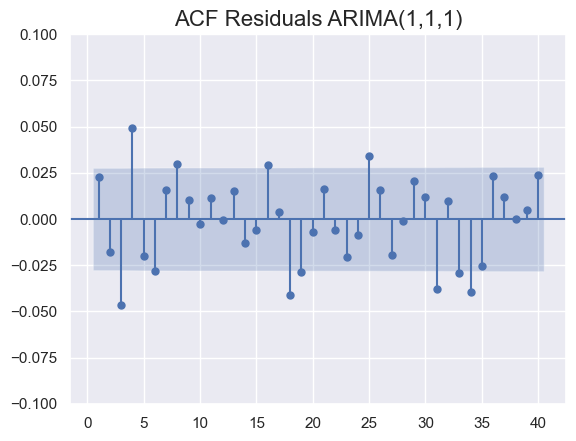

In [15]:
# ACF On Residuals of ARIMA(1,1,1)
sgt.plot_acf(df.resid_arima_111[1:],zero=False,lags=40)
plt.title("ACF Residuals ARIMA(1,1,1)",size=16)
plt.ylim(-.1,.1)
plt.show()

`From Dickey Fuller Test and ACF We confirm that :`                                                                       
`(i) The Data is Stationary i.e Residuals mimic White noise`                                                               
`(ii) There are 7 significant lags and from which we have to check lag = 3 & 4 to check if we get better model`

## Higher-Lag ARIMA Models

#### We will check all the models between ARIMA(1,1,1) and ARIMA(4,1,4) to get the best one

In [19]:
dict_llf = {}
dict_aic = {}
dict_models = {}
for i in range(1,5):
    for j in range(1,5):
        print(f"Result \t ARIMA({i},1,{j}) -> \n")
        model = ARIMA(df.market_value, order=(i,1,j))
        result= model.fit()
        print(result.summary())

        dict_models[f'ARIMA({i},1,{j})'] = model
        dict_llf[f'ARIMA({i},1,{j}) llf'] = result.llf 
        dict_aic[f'ARIMA({i},1,{j}) aic'] = result.aic 


Result 	 ARIMA(1,1,1) -> 

                               SARIMAX Results                                
Dep. Variable:           market_value   No. Observations:                 5021
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -27604.005
Date:                Tue, 28 Apr 2026   AIC                          55214.010
Time:                        10:26:21   BIC                          55233.574
Sample:                    01-07-1994   HQIC                         55220.865
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7459      0.059     12.656      0.000       0.630       0.861
ma.L1         -0.7919      0.053    -14.927      0.000      -0.896      -0.688
sigma2      3498.6529    

`Models Worth Checking -> 113,213,311,312 are worth checking`

In [29]:
# Running LLR Tests To get the best Model
print(LLR_test(dict_models["ARIMA(1,1,3)"],dict_models["ARIMA(2,1,3)"]))
#print(LLR_test(dict_models["ARIMA(1,1,3)"],dict_models["ARIMA(3,1,1)"])) # cannot compare with LLR Same DF
#print(LLR_test(dict_models["ARIMA(1,1,3)"],dict_models["ARIMA(3,1,2)"])) # Not nested cannot use LLR
#print(LLR_test(dict_models["ARIMA(2,1,3)"],dict_models["ARIMA(3,1,1)"])) # Not Nested 
#print(LLR_test(dict_models["ARIMA(2,1,3)"],dict_models["ARIMA(3,1,2)"])) # cannot compare 
print(LLR_test(dict_models["ARIMA(3,1,1)"],dict_models["ARIMA(3,1,2)"]))

0.237
0.092


`Using LLR we found ARIMA(1,1,3) > ARIMA(2,1,3)`                                                                           
`ARIMA(3,1,1) > ARIMA(3,1,2)`

In [30]:
# We manually check for Other models

# ARIMA(1,1,3) vs ARIMA(3,1,1)
print(f'ARIMA(1,1,3) ->\tLog-Likelihood Value -> {dict_llf['ARIMA(1,1,3) llf']}\t AIC Value -> {dict_aic['ARIMA(1,1,3) aic']}')
print(f'ARIMA(3,1,1) ->\tLog-Likelihood Value -> {dict_llf['ARIMA(3,1,1) llf']}\t AIC Value -> {dict_aic['ARIMA(3,1,1) aic']}')

ARIMA(1,1,3) ->	Log-Likelihood Value -> -27590.72348195203	 AIC Value -> 55191.44696390406
ARIMA(3,1,1) ->	Log-Likelihood Value -> -27592.33611647482	 AIC Value -> 55194.67223294964


`ARIMA(1,1,3) > ARIMA(3,1,1)`

`From This we can conclude that ARIMA(1,1,3) is the best fit model For FTSE prices with integration = 1`

In [31]:
# Residuals of ARIMA(1,1,3)
df['resid_arima_113'] = dict_models['ARIMA(1,1,3)'].fit().resid[1:]

In [32]:
df.head()

,spx,dax,ftse,nikkei,market_value,returns,resid_arima_111,resid_arima_113
date,,,,,,,,
1994-01-07,469.90,2224.95,3445.98,18124.01,3445.98,NaN,NaN,NaN
1994-01-10,475.27,2225.00,3440.58,18443.44,3440.58,-0.156704,-4.890072,-5.193251
1994-01-11,474.13,2228.10,3413.77,18485.25,3413.77,-0.779229,-26.636216,-26.291777
1994-01-12,474.17,2182.06,3372.02,18793.88,3372.02,-1.222988,-42.783165,-41.502414
1994-01-13,472.47,2142.37,3360.01,18577.26,3360.01,-0.356166,-14.685950,-15.055949


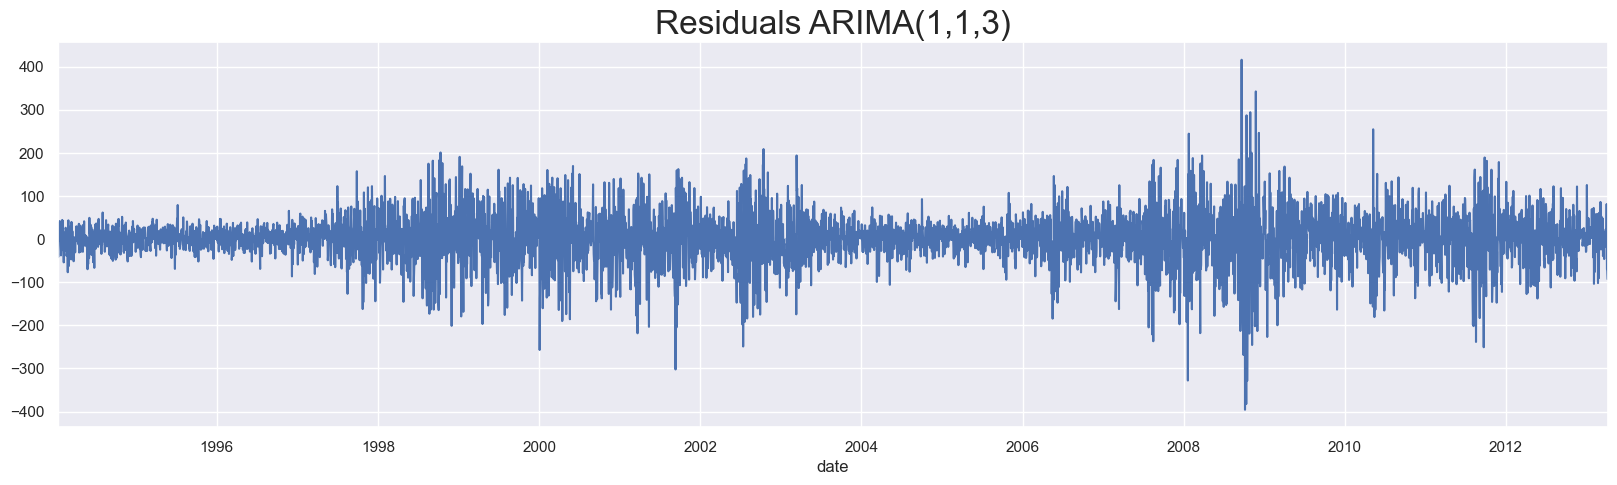

In [34]:
# Plotting Residuals and ACF
df.resid_arima_113[1:].plot(figsize=(20,5))
plt.title("Residuals ARIMA(1,1,3)",size=24)
plt.show()

In [36]:
#Augmented Dickey Fuller Test
sts.adfuller(df.resid_arima_113[1:])

(np.float64(-30.499886278892212),
 0.0,
 5,
 5014,
 {'1%': np.float64(-3.4316548765428174),
  '5%': np.float64(-2.8621166146845334),
  '10%': np.float64(-2.5670769326348926)},
 np.float64(54847.2513293987))

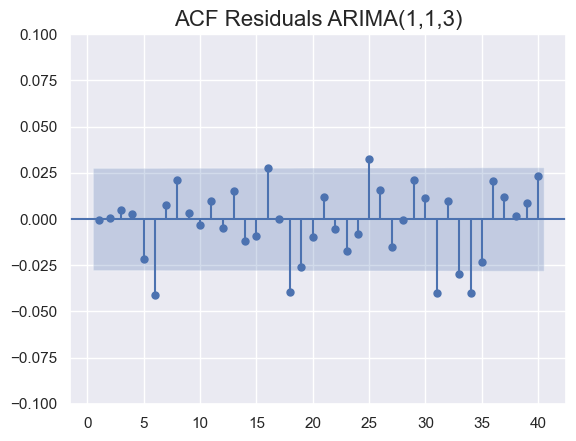

In [37]:
# ACF

sgt.plot_acf(df.resid_arima_113[1:],zero=False,lags=40)
plt.title("ACF Residuals ARIMA(1,1,3)",size=16)
plt.ylim(-.1,.1)
plt.show()


`This shows that there is a possibility of better fit with AR or MA component = 6`

In [39]:
for i in range(5,7):
    for j in range(1,7):
        print(f"Result \t ARIMA({i},1,{j}) -> \n")
        model = ARIMA(df.market_value, order=(i,1,j))
        result= model.fit()
        print(result.summary())

        dict_models[f'ARIMA({i},1,{j})'] = model
        dict_llf[f'ARIMA({i},1,{j}) llf'] = result.llf 
        dict_aic[f'ARIMA({i},1,{j}) aic'] = result.aic 

Result 	 ARIMA(5,1,1) -> 

                               SARIMAX Results                                
Dep. Variable:           market_value   No. Observations:                 5021
Model:                 ARIMA(5, 1, 1)   Log Likelihood              -27586.845
Date:                Tue, 28 Apr 2026   AIC                          55187.689
Time:                        11:01:24   BIC                          55233.338
Sample:                    01-07-1994   HQIC                         55203.685
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4006      0.153      2.618      0.009       0.101       0.701
ar.L2         -0.0444      0.011     -4.071      0.000      -0.066      -0.023
ar.L3         -0.0542    

`511, 512 were found to be worth checking`

In [41]:
# since 511 is nested in 512 we can perform LLR Test
# ARIMA(5,1,1) vs ARIMA(5,1,2)
LLR_test(dict_models['ARIMA(5,1,1)'],dict_models['ARIMA(5,1,2)'])

np.float64(0.028)

In [42]:
# We got better results with ARIMA(5,1,2)
# Now compare ARIMA(1,1,3) with ARIMA(5,1,2) Since not nested we manually check
print(f'ARIMA(1,1,3) ->\tLog-Likelihood Value -> {dict_llf['ARIMA(1,1,3) llf']}\t AIC Value -> {dict_aic['ARIMA(1,1,3) aic']}')
print(f'ARIMA(5,1,2) ->\tLog-Likelihood Value -> {dict_llf['ARIMA(5,1,2) llf']}\t AIC Value -> {dict_aic['ARIMA(5,1,2) aic']}')

ARIMA(1,1,3) ->	Log-Likelihood Value -> -27590.72348195203	 AIC Value -> 55191.44696390406
ARIMA(5,1,2) ->	Log-Likelihood Value -> -27584.44496474866	 AIC Value -> 55184.88992949732


`Looking at this :`                                                                                                      
`Log Likelihood Increased and AIC Decreased Thus ARIMA(5,1,2) is the better fit model`

In [43]:
# Residuals of ARIMA(5,1,2)
df['resid_arima_512'] = dict_models['ARIMA(5,1,2)'].fit().resid[1:]

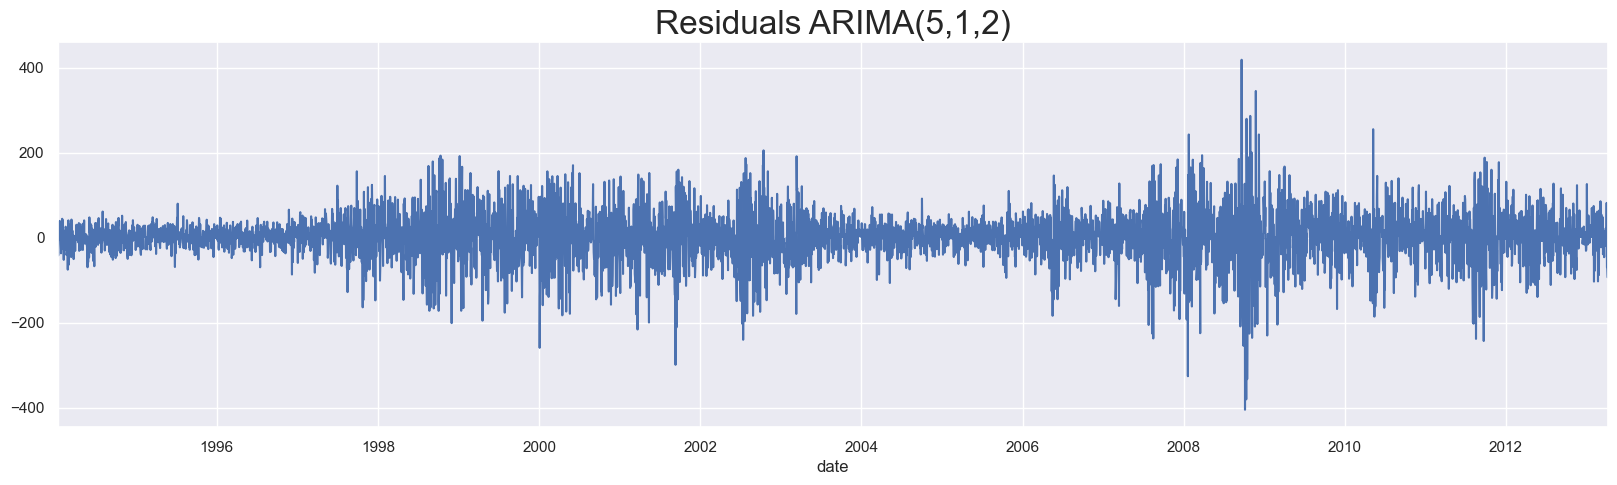

In [44]:
# Plot
df.resid_arima_512[1:].plot(figsize=(20,5))
plt.title("Residuals ARIMA(5,1,2)",size=24)
plt.show()

In [45]:
# Augmented Dickey Fuller Test
sts.adfuller(df.resid_arima_512[1:])

(np.float64(-70.86147638953953),
 0.0,
 0,
 5019,
 {'1%': np.float64(-3.4316535759402753),
  '5%': np.float64(-2.8621160400844468),
  '10%': np.float64(-2.567076626752987)},
 np.float64(54835.792826476514))

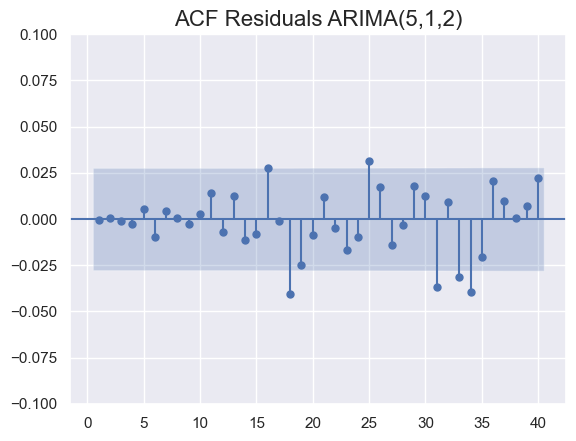

In [46]:
# ACF 
sgt.plot_acf(df.resid_arima_512[1:],zero=False,lags=40)
plt.title("ACF Residuals ARIMA(5,1,2)",size=16)
plt.ylim(-.1,.1)
plt.show()

`Look at that -> AMAZING First 15 lags are insignificant  Thus ARIMA(5,1,2) is the best choice `

## Models with Higher Levels of Integration

In [ ]:
# If we get our data stationary after just one integration, why need to complicate it by increasing lags

## ARIMAX 

In [47]:
# exogeneous -> variables which are outside the data but affects the data like Say, other money indexes or Any other data
# To make ARIMAX model we must have external data with all the periods.
# Making Exog as spx, dax, and nikkei to check if they influence the model
model_arima_111_Xspx = ARIMA(df.market_value, exog=df.spx, order=(1,1,1))
result_arima_111_Xspx = model_arima_111_Xspx.fit()
print(result_arima_111_Xspx.summary())

                               SARIMAX Results                                
Dep. Variable:           market_value   No. Observations:                 5021
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -26693.392
Date:                Tue, 28 Apr 2026   AIC                          53394.784
Time:                        11:32:47   BIC                          53420.869
Sample:                    01-07-1994   HQIC                         53403.925
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
spx            2.6928      0.035     76.407      0.000       2.624       2.762
ar.L1          0.2571      0.029      8.812      0.000       0.200       0.314
ma.L1         -0.5460      0.025    -21.791      0.0

`With Exog as spx data our model became worse than ARIMA(1,1,1)`

In [48]:
#Checking DAX AND NIKKEI
model_arima_111_Xdax = ARIMA(df.market_value, exog=df.dax, order=(1,1,1))
result_arima_111_Xdax = model_arima_111_Xdax.fit()
print(result_arima_111_Xdax.summary())

model_arima_111_Xnikkei = ARIMA(df.market_value, exog=df.nikkei, order=(1,1,1))
result_arima_111_Xnikkei = model_arima_111_Xnikkei.fit()
print(result_arima_111_Xnikkei.summary())

                               SARIMAX Results                                
Dep. Variable:           market_value   No. Observations:                 5021
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -25049.811
Date:                Tue, 28 Apr 2026   AIC                          50107.623
Time:                        11:34:51   BIC                          50133.707
Sample:                    01-07-1994   HQIC                         50116.763
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
dax            0.6306      0.004    148.424      0.000       0.622       0.639
ar.L1          0.6378      0.067      9.537      0.000       0.507       0.769
ma.L1         -0.7024      0.063    -11.149      0.0

`Is ARIMA(1,1,1)Xdax performing better than ARIMA(1,1,1) after looking at Log likelihood ratios and AIC AND BIC`

In [50]:
# LLR TEST For ARIMA(1,1,1)Xdax with ARIMA(5,1,2)
LLR_test(model_arima_111_Xdax,dict_models['ARIMA(5,1,2)'],DF=5)

np.float64(1.0)

`Does this tell That ARIMAX(1,1,1) performs better than ARIMA(5,1,2)`

In [52]:
df['resid_arimax_111'] = result_arima_111_Xdax.resid[1:]
# Residual ACF AND ADF TEST FOR ARIMAX(1,1,1)
sts.adfuller(df.resid_arimax_111[1:])

(np.float64(-20.494610212616127),
 0.0,
 10,
 5009,
 {'1%': np.float64(-3.431656179743224),
  '5%': np.float64(-2.8621171904320923),
  '10%': np.float64(-2.5670772391276855)},
 np.float64(49782.53615188756))

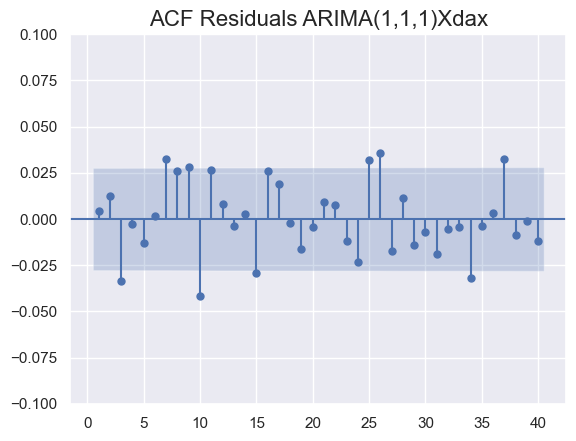

In [54]:
# ACF
sgt.plot_acf(df.resid_arimax_111[1:],zero=False,lags=40)
plt.title("ACF Residuals ARIMA(1,1,1)Xdax",size=16)
plt.ylim(-.1,.1)
plt.show()

`No it is not performing better `                                        

`Reasons- Firstly we are comparing ARIMAX(1,1,1) with ARIMA(5,1,2)`        

`Try ARIMAX(5,1,2) with exog = dax non stationary right now`               

 `Then Try ARIMAX(5,1,2) with exog = daxx_differenced making exog stationary too`

In [ ]:
# Fitting ARIMAX(1,1,1) with exog = dax_differenced
df['dax_diff'] = df.dax.diff(1)
df.dax_diff = df.dax_diff.bfill() # just to remove nan from first data

In [67]:
df.head()

,spx,dax,ftse,nikkei,market_value,returns,resid_arima_111,resid_arima_113,resid_arima_512,resid_arimax_111,dax_diff
date,,,,,,,,,,,
1994-01-07,469.90,2224.95,3445.98,18124.01,3445.98,NaN,NaN,NaN,NaN,NaN,0.05
1994-01-10,475.27,2225.00,3440.58,18443.44,3440.58,-0.156704,-4.890072,-5.193251,-5.182990,-5.276439,0.05
1994-01-11,474.13,2228.10,3413.77,18485.25,3413.77,-0.779229,-26.636216,-26.291777,-26.306637,-28.981162,3.10
1994-01-12,474.17,2182.06,3372.02,18793.88,3372.02,-1.222988,-42.783165,-41.502414,-41.639719,-14.656238,-46.04
1994-01-13,472.47,2142.37,3360.01,18577.26,3360.01,-0.356166,-14.685950,-15.055949,-15.092926,10.852484,-39.69


In [68]:
model_arima_111_Xdax_diff = ARIMA(df.market_value[1:], exog=df.dax_diff[1:], order=(1,1,1))
result_arima_111_Xdax_diff = model_arima_111_Xdax_diff.fit()
print(result_arima_111_Xdax_diff.summary())

                               SARIMAX Results                                
Dep. Variable:           market_value   No. Observations:                 5020
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -26574.404
Date:                Tue, 28 Apr 2026   AIC                          53156.808
Time:                        11:55:03   BIC                          53182.892
Sample:                    01-10-1994   HQIC                         53165.948
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
dax_diff       0.3110      0.004     84.409      0.000       0.304       0.318
ar.L1         -0.1278      0.045     -2.813      0.005      -0.217      -0.039
ma.L1          0.3316      0.043      7.629      0.0

In [70]:
# Checking with residuals
df['resid_arimax_111_diff'] = result_arima_111_Xdax_diff.resid[1:]
# Residual ACF AND ADF TEST FOR ARIMAX(1,1,1)
sts.adfuller(df.resid_arimax_111_diff[2:])

(np.float64(-32.0554316927932),
 0.0,
 5,
 5013,
 {'1%': np.float64(-3.431655136974821),
  '5%': np.float64(-2.8621167297421373),
  '10%': np.float64(-2.567076993884522)},
 np.float64(52785.58665407389))

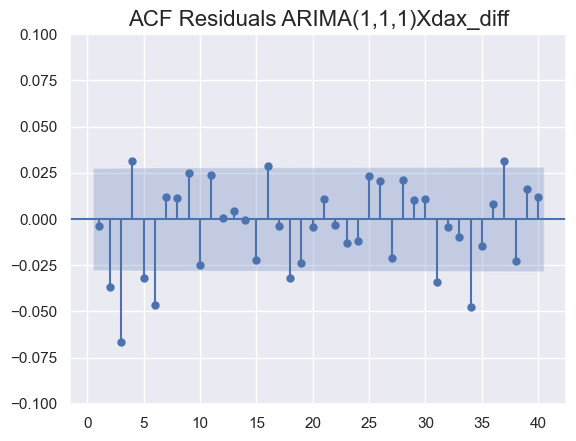

In [73]:
# ACF
sgt.plot_acf(df.resid_arimax_111_diff[2:],zero=False,lags=40)
plt.title("ACF Residuals ARIMA(1,1,1)Xdax_diff",size=16)
plt.ylim(-.1,.1)
plt.show()

In [74]:
# Let us Try ARIMAX(5,1,2)Xdax and ARIMAX(5,1,2)Xdax_diff
model_arima_512_Xdax = ARIMA(df.market_value, exog=df.dax, order=(5,1,2))
result_arima_512_Xdax = model_arima_512_Xdax.fit()
print(result_arima_512_Xdax.summary())

model_arima_512_Xdax_diff = ARIMA(df.market_value[1:], exog=df.dax_diff[1:], order=(5,1,2))
result_arima_512_Xdax_diff = model_arima_512_Xdax_diff.fit()
print(result_arima_512_Xdax_diff.summary())

                               SARIMAX Results                                
Dep. Variable:           market_value   No. Observations:                 5021
Model:                 ARIMA(5, 1, 2)   Log Likelihood              -25045.453
Date:                Tue, 28 Apr 2026   AIC                          50108.905
Time:                        11:59:39   BIC                          50167.596
Sample:                    01-07-1994   HQIC                         50129.471
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
dax            0.6305      0.004    145.986      0.000       0.622       0.639
ar.L1         -0.3235      5.509     -0.059      0.953     -11.120      10.473
ar.L2          0.2707      1.995      0.136      0.8

In [75]:
# Residuals of following 
df['resid_arimax_512'] = result_arima_512_Xdax.resid[1:]
# Residual ACF AND ADF TEST FOR ARIMAX(5,1,2)
sts.adfuller(df.resid_arimax_512[2:])


(np.float64(-13.017310404505935),
 np.float64(2.495447869342932e-24),
 25,
 4993,
 {'1%': np.float64(-3.431660367533127),
  '5%': np.float64(-2.862119040575461),
  '10%': np.float64(-2.5670782240311683)},
 np.float64(49771.96849492568))

In [76]:
df['resid_arimax_512_diff'] = result_arima_512_Xdax_diff.resid[1:]
# Residual ACF AND ADF TEST FOR ARIMAX(1,1,1)
sts.adfuller(df.resid_arimax_512_diff[2:])

(np.float64(-70.8523027137931),
 0.0,
 0,
 5018,
 {'1%': np.float64(-3.4316538358533277),
  '5%': np.float64(-2.8621161549128313),
  '10%': np.float64(-2.567076687880585)},
 np.float64(52775.5492753826))

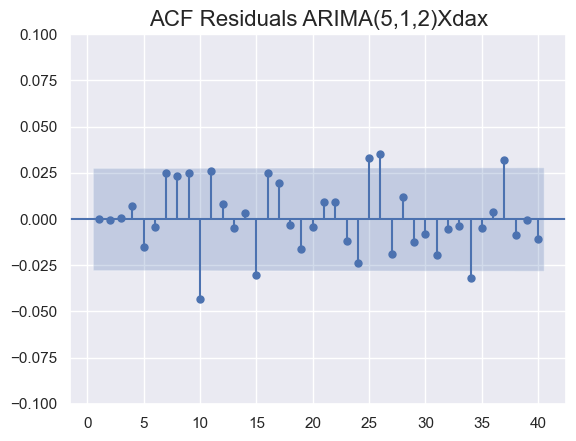

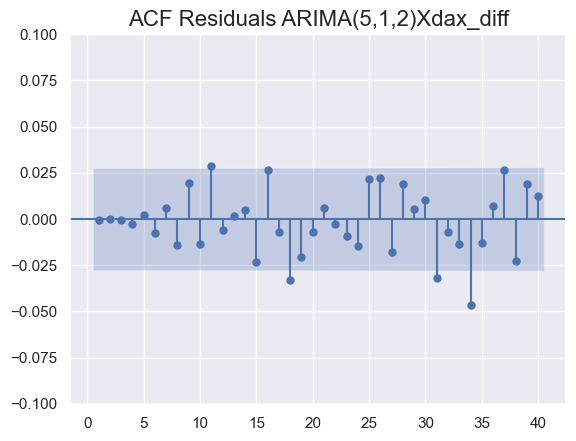

In [78]:
# ACF 
sgt.plot_acf(df.resid_arimax_512[2:],zero=False,lags=40)
plt.title("ACF Residuals ARIMA(5,1,2)Xdax",size=16)
plt.ylim(-.1,.1)
plt.show()
sgt.plot_acf(df.resid_arimax_512_diff[2:],zero=False,lags=40)
plt.title("ACF Residuals ARIMA(5,1,2)Xdax_diff",size=16)
plt.ylim(-.1,.1)
plt.show()

`Clearly ARIMA(5,1,2)Xdax_diff is the best fit model`

## SARIMAX

In [79]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [86]:
# This allows us to input seasonal patterns inside the model fitting making the model predict better
model_sarimax_101_2015 = SARIMAX(df.returns, exog=df.dax_diff, order=(1,0,1), seasonal_order=(2,0,1,5))
result_sarimax_101_2015 = model_sarimax_101_2015.fit()
print(result_sarimax_101_2015.summary())

                                     SARIMAX Results                                     
Dep. Variable:                           returns   No. Observations:                 5021
Model:             SARIMAX(1, 0, 1)x(2, 0, 1, 5)   Log Likelihood               -5523.258
Date:                           Tue, 28 Apr 2026   AIC                          11060.516
Time:                                   12:16:45   BIC                          11106.165
Sample:                               01-07-1994   HQIC                         11076.512
                                    - 04-05-2013                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
dax_diff       0.0122   8.07e-05    151.561      0.000       0.012       0.012
ar.L1          0.4531      0.109      4.170

In [87]:
# Residual 
df['resid_sarimax_101_2015'] = result_sarimax_101_2015.resid[1:]
# Residual ACF AND ADF TEST FOR SARIMAX(1,0,1)x(2,0,1,5)
sts.adfuller(df.resid_sarimax_101_2015[2:])

(np.float64(-24.2618227385434),
 0.0,
 7,
 5011,
 {'1%': np.float64(-3.4316556581508197),
  '5%': np.float64(-2.862116959995152),
  '10%': np.float64(-2.567077116457145)},
 np.float64(10962.688615864196))

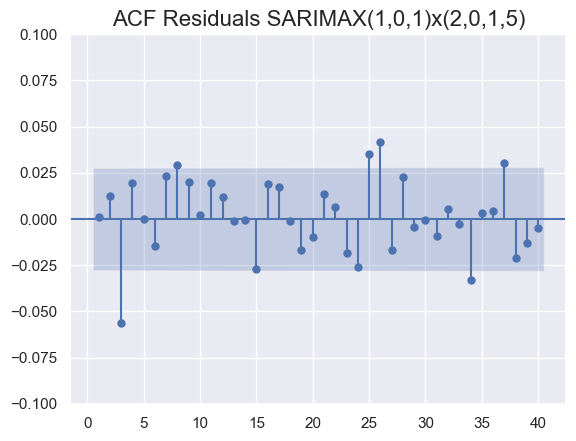

In [89]:
# ACF
sgt.plot_acf(df.resid_sarimax_101_2015[2:],zero=False,lags=40)
plt.title("ACF Residuals SARIMAX(1,0,1)x(2,0,1,5)",size=16)
plt.ylim(-.1,.1)
plt.show()